In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("spam.csv", encoding='latin1')

In [3]:
# To detect encoding type in any file
%pip install chardet



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import chardet
with open('spam.csv', 'rb') as f: #IMP open in binary-mode
    text = f.read(5000)

encoding = chardet.detect(text)
print("encoder result: ", encoding)

encoder result:  {'encoding': 'Windows-1252', 'confidence': 0.7197765921973991, 'language': ''}


In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.shape

(5572, 5)

Steps We will be Performing:
> Data Cleaning  
> Exploratory Data Analysis (EDA)  
> Text Preprocessing  
> Model Building  
> Evaluation  
> Improvement  
> Website  
> Deploy

## 1. Data Cleaning
Includes:  
Dropping Unnecessary Columns,  
Renaming the columns if necessary,  
Encoding the target variable,  
Checking for missing values or duplicate values and act accordingly

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [8]:
df.drop(columns=['Unnamed: 2','Unnamed: 3', 'Unnamed: 4'], inplace=True) #IMP - I almost forgot inplace

In [9]:
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)

In [10]:
df.sample(5)

,target,text
1254,ham,What your plan for pongal?
3278,ham,Solve d Case : A Man Was Found Murdered On &l...
1106,ham,"Good afternoon, my love. How goes your day ? W..."
5121,ham,"Oops I did have it, &lt;#&gt; ?"
3962,ham,If you ask her or she say any please message.


In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
encoder = LabelEncoder()

df['target'] = encoder.fit_transform(df['target'])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df.isna().sum()

target    0
text      0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(403)

In [15]:
df.drop_duplicates(keep='first', inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

## 2. Exploratory Data Analysis (EDA)

In [17]:
# 1. Check data imbalances
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x785db1d54d10>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

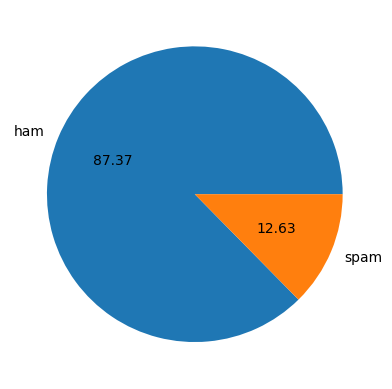

In [22]:
import matplotlib.pyplot as plt

plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')

In [ ]:
# Data is imbalanced, We need to keep this in mind

# we will count no. of characters, words and sentences
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /home/sakshi-
[nltk_data]     khatiwada/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [27]:
df['number_of_characters'] = df['text'].apply(len)

In [28]:
df.head()

,target,text,number_of_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [34]:
df['number_of_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [35]:
df['number_of_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [36]:
df.head()

,target,text,number_of_characters,number_of_words,number_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [37]:
df[['number_of_characters', 'number_of_words', 'number_of_sentences']].describe()

,number_of_characters,number_of_words,number_of_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
df[df['target'] == 0][['number_of_characters', 'number_of_words', 'number_of_sentences']].describe() # ham's description

,number_of_characters,number_of_words,number_of_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [41]:
df[df['target'] == 1][['number_of_characters', 'number_of_words', 'number_of_sentences']].describe() # spam's description

,number_of_characters,number_of_words,number_of_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [43]:
import seaborn as sns

<Axes: xlabel='number_of_characters', ylabel='Count'>

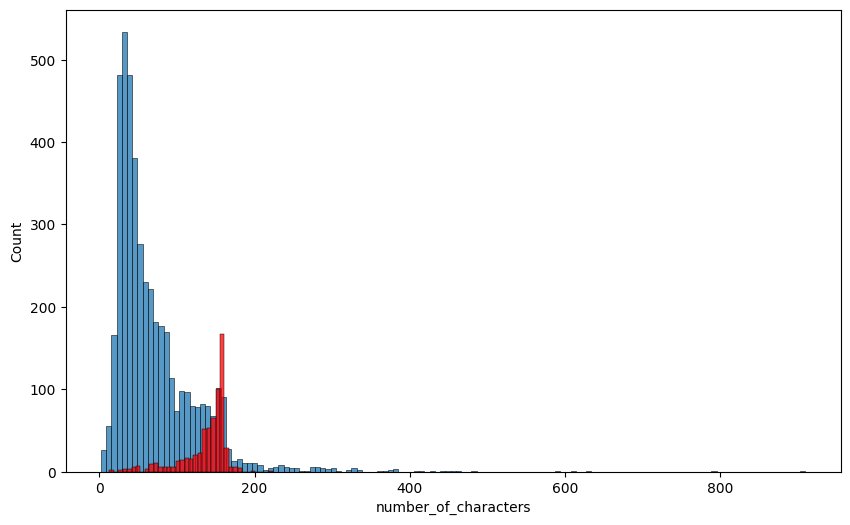

In [48]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['target'] == 0]['number_of_characters'])
sns.histplot(df[df['target'] == 1]['number_of_characters'], color='red')

<Axes: xlabel='number_of_words', ylabel='Count'>

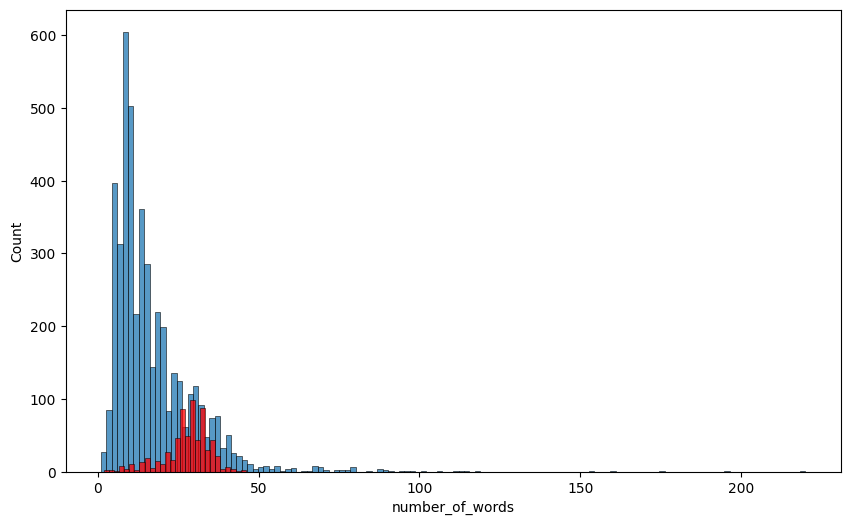

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['target'] == 0]['number_of_words'])
sns.histplot(df[df['target'] == 1]['number_of_words'], color='red')

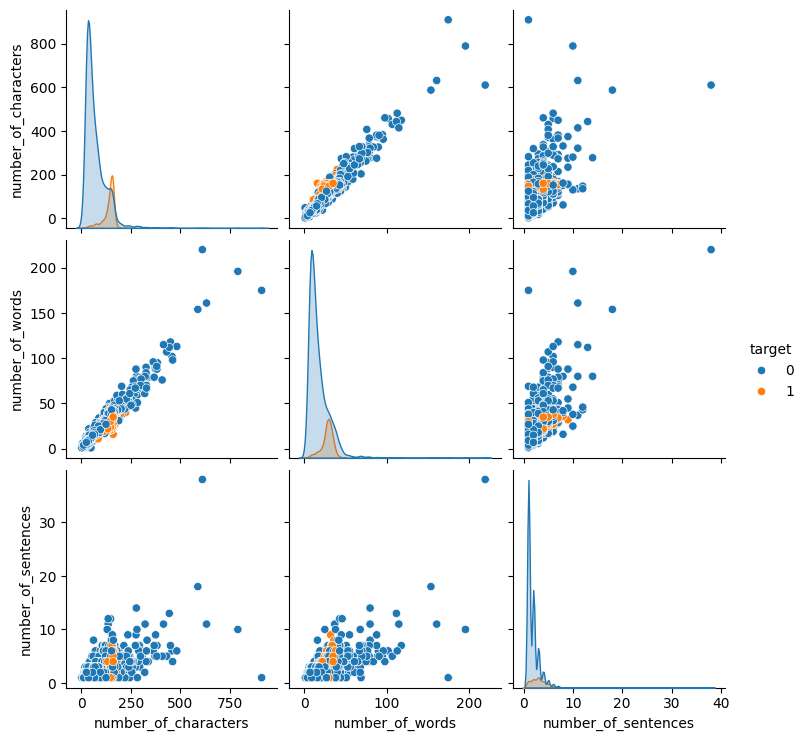

In [51]:
sns.pairplot(df, hue='target')

<Axes: >

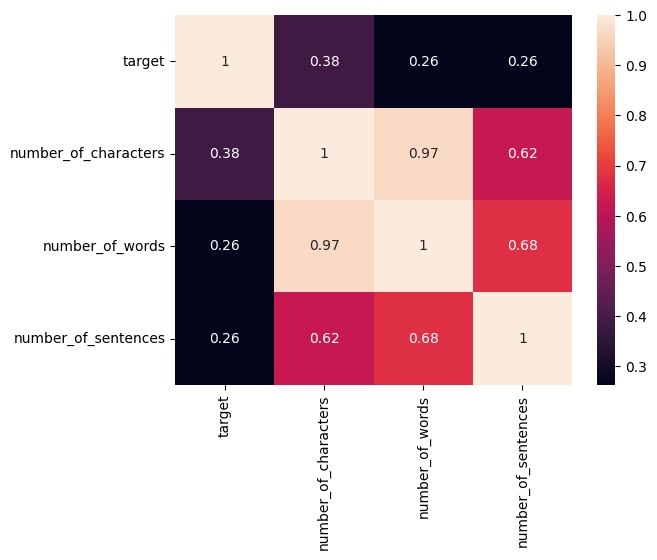

In [59]:
# sns.heatmap(df.corr()) # not supposed to throw error but did. Didn't implicitly ignored non-numeric column

# df.select_dtypes(include='number').corr()
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)